<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_full_io_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STATE: FULL_IO_LOOP_LOCKED
input sequence:   10110101
decoded sequence: 10110101
stored sequence:  10110101
readout sequence: 10110101
decode accuracy: 1.0
memory accuracy: 1.0
readout accuracy: 1.0
full loop accuracy: 1.0


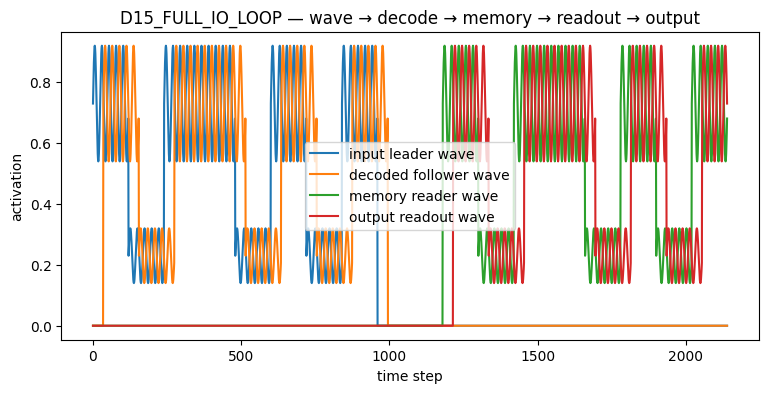

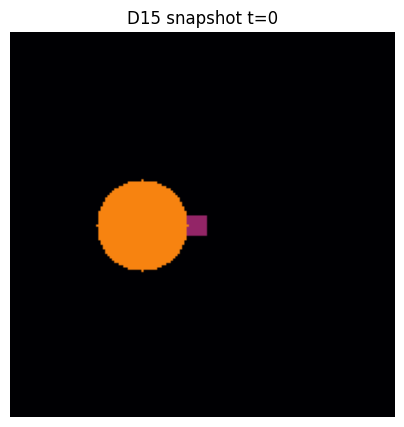

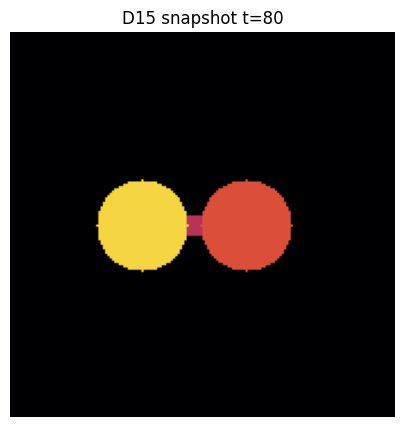

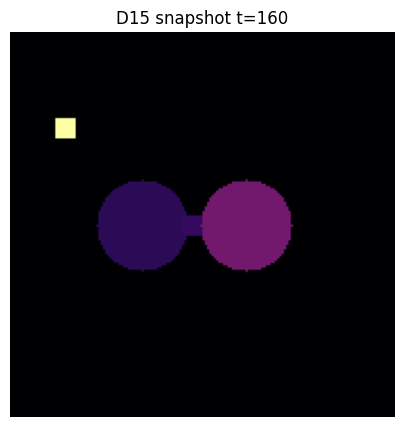

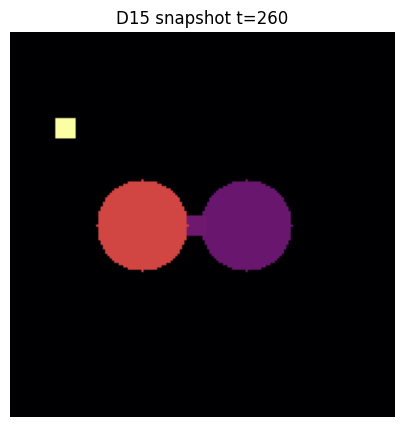

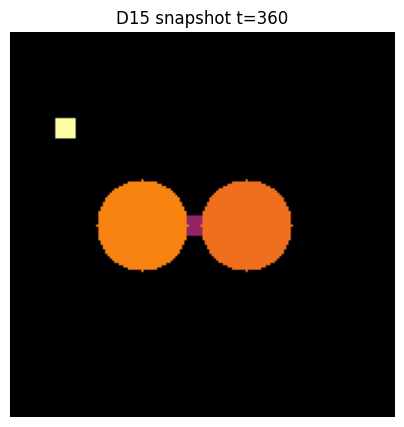

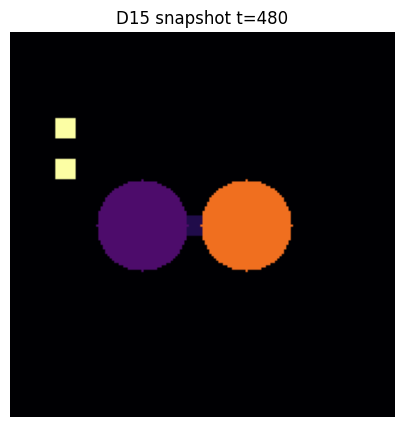

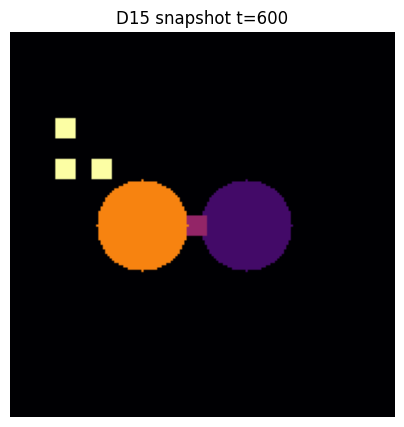

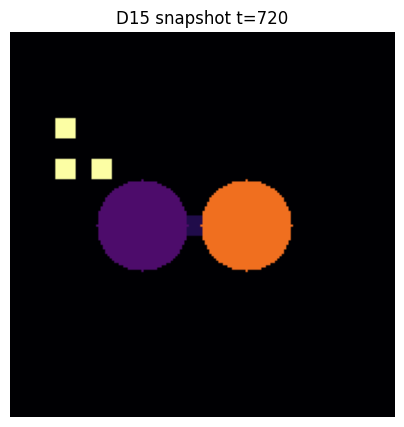

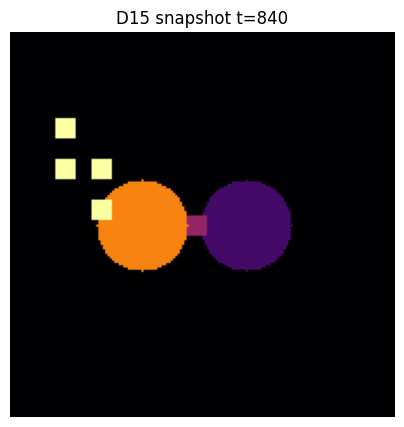

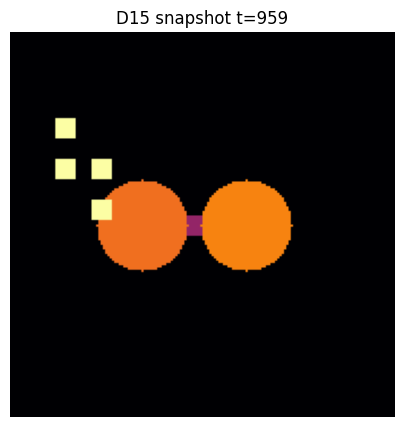

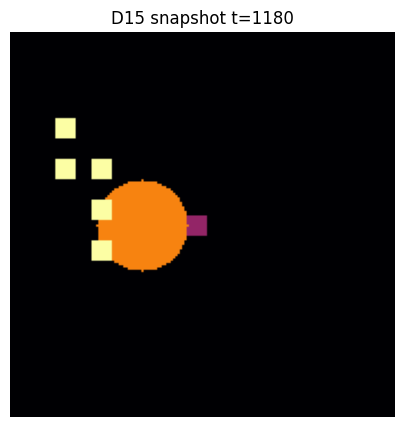

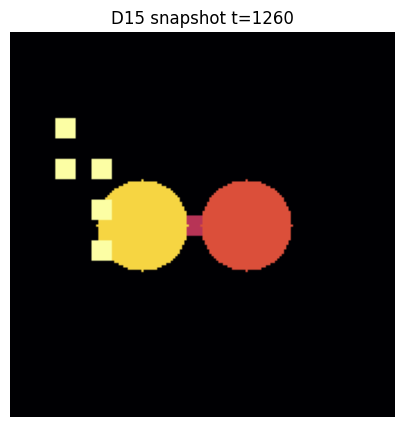

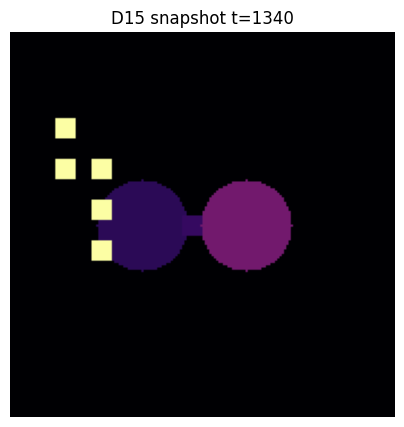

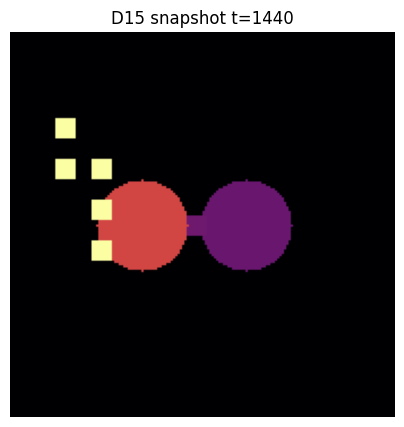

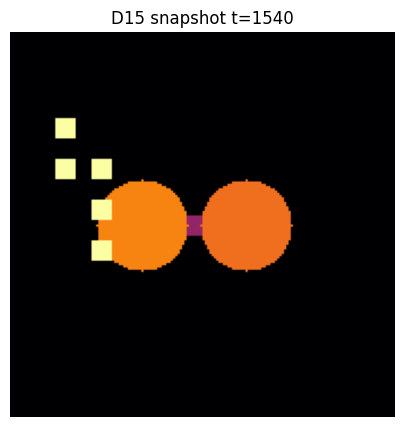

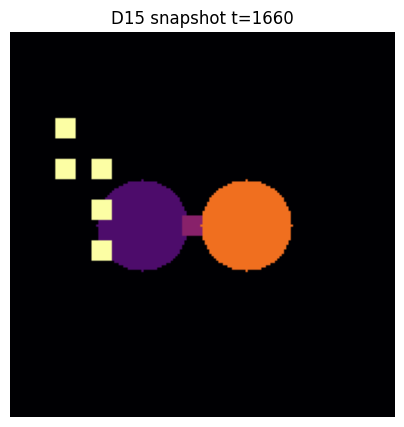

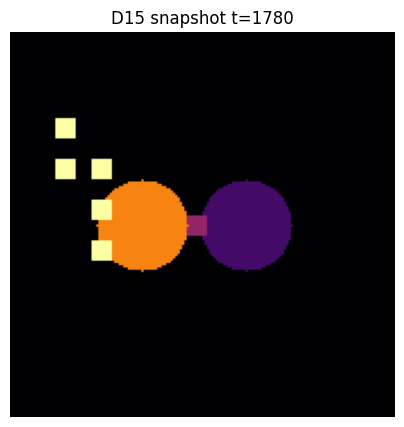

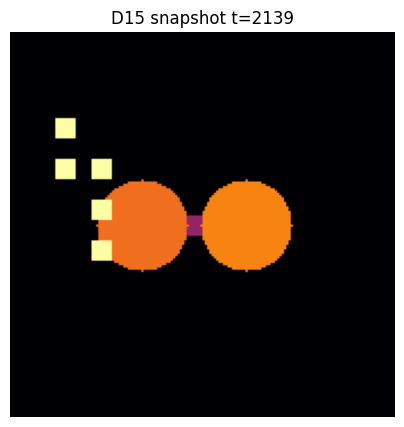

Decoded bits:


,STATE,BIT_INDEX,INPUT_BIT,RECEIVED_MEAN,DECODED_BIT,MEMORY_VALUE_AFTER_WRITE,MATCH
0,D15_FULL_IO_LOOP,0,1,0.747,1,1.0,1
1,D15_FULL_IO_LOOP,1,0,0.238,0,0.0,1
2,D15_FULL_IO_LOOP,2,1,0.747,1,1.0,1
3,D15_FULL_IO_LOOP,3,1,0.747,1,1.0,1
4,D15_FULL_IO_LOOP,4,0,0.238,0,0.0,1
5,D15_FULL_IO_LOOP,5,1,0.747,1,1.0,1
6,D15_FULL_IO_LOOP,6,0,0.238,0,0.0,1
7,D15_FULL_IO_LOOP,7,1,0.747,1,1.0,1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# D15_FULL_IO_LOOP
# input wave -> decode -> memory write -> hold -> readout -> output wave
# ============================================================

STATE_NAME = "D15_FULL_IO_LOOP"

input_sequence = "10110101"
bit_len = 120
decode_delay = 35
decode_threshold = 0.38
hold_len = 220

n_bits = len(input_sequence)
write_len = n_bits * bit_len
read_start = write_len + hold_len
read_len = n_bits * bit_len
total_steps = write_len + hold_len + read_len

size = 170
Y, X = np.mgrid[:size, :size]

left_center = (58, 85)
right_center = (104, 85)
cell_radius = 20

left_cell = (X - left_center[0])**2 + (Y - left_center[1])**2 <= cell_radius**2
right_cell = (X - right_center[0])**2 + (Y - right_center[1])**2 <= cell_radius**2

bridge = (
    (X >= left_center[0] + cell_radius - 2)
    & (X <= right_center[0] - cell_radius + 2)
    & (Y >= left_center[1] - 4)
    & (Y <= left_center[1] + 4)
)

# memory slots on the left side: 8 bounded cells
memory_masks = []
slot_size = 9
x0 = 20
y0 = 38

for i in range(n_bits):
    row = i // 2
    col = i % 2
    x1 = x0 + col * 16
    y1 = y0 + row * 18
    mask = (
        (X >= x1)
        & (X < x1 + slot_size)
        & (Y >= y1)
        & (Y < y1 + slot_size)
    )
    memory_masks.append(mask)

def wave_value(bit, local_t, period=24):
    carrier = 0.5 + 0.5 * np.sin(2 * np.pi * local_t / period)

    if int(bit) == 1:
        return 0.54 + 0.38 * carrier
    else:
        return 0.14 + 0.18 * carrier

leader_signal = np.zeros(total_steps)
follower_signal = np.zeros(total_steps)
bridge_signal = np.zeros(total_steps)
memory_reader_signal = np.zeros(total_steps)
output_signal = np.zeros(total_steps)

memory_history = np.zeros((total_steps, n_bits))

# ============================================================
# Phase 1: input wave transmission and memory write
# ============================================================

decoded_bits = []
memory_values_after_write = []

for i, bit in enumerate(input_sequence):
    start = i * bit_len
    end = start + bit_len

    for t in range(start, end):
        local_t = t - start
        leader_signal[t] = wave_value(bit, local_t)
        bridge_signal[t] = 0.55 * leader_signal[t]

    delayed_start = start + decode_delay
    delayed_end = min(end + decode_delay, total_steps)

    for t in range(delayed_start, delayed_end):
        local_t = t - delayed_start
        follower_signal[t] = wave_value(bit, local_t)
        bridge_signal[t] = max(bridge_signal[t], 0.55 * follower_signal[t])

    decode_window_start = start + decode_delay
    decode_window_end = min(start + bit_len, total_steps)
    received_mean = float(follower_signal[decode_window_start:decode_window_end].mean())

    decoded_bit = 1 if received_mean >= decode_threshold else 0
    decoded_bits.append(decoded_bit)

    memory_value = 1.0 if decoded_bit == 1 else 0.0
    memory_values_after_write.append(memory_value)

    write_time = min(end + decode_delay, total_steps - 1)
    memory_history[write_time:, i] = memory_value

# ============================================================
# Phase 2: memory hold
# ============================================================

for t in range(write_len, read_start):
    memory_history[t, :] = memory_values_after_write

# ============================================================
# Phase 3: memory readout back into output wave
# ============================================================

readout_bits = []

for i, stored_value in enumerate(memory_values_after_write):
    bit = 1 if stored_value >= 0.5 else 0

    start = read_start + i * bit_len
    end = start + bit_len

    for t in range(start, end):
        local_t = t - start
        memory_reader_signal[t] = wave_value(bit, local_t)
        bridge_signal[t] = max(bridge_signal[t], 0.55 * memory_reader_signal[t])

    delayed_start = start + decode_delay
    delayed_end = min(end + decode_delay, total_steps)

    for t in range(delayed_start, delayed_end):
        local_t = t - delayed_start
        output_signal[t] = wave_value(bit, local_t)
        bridge_signal[t] = max(bridge_signal[t], 0.55 * output_signal[t])

    decode_window_start = start + decode_delay
    decode_window_end = min(start + bit_len, total_steps)
    output_mean = float(output_signal[decode_window_start:decode_window_end].mean())

    readout_bit = 1 if output_mean >= decode_threshold else 0
    readout_bits.append(readout_bit)

# ============================================================
# Tables
# ============================================================

decoded_sequence = "".join(str(x) for x in decoded_bits)
stored_sequence = "".join(str(int(v >= 0.5)) for v in memory_values_after_write)
readout_sequence = "".join(str(x) for x in readout_bits)

decode_accuracy = sum(
    int(a == b) for a, b in zip(input_sequence, decoded_sequence)
) / n_bits

memory_accuracy = sum(
    int(a == b) for a, b in zip(input_sequence, stored_sequence)
) / n_bits

readout_accuracy = sum(
    int(a == b) for a, b in zip(stored_sequence, readout_sequence)
) / n_bits

full_loop_accuracy = sum(
    int(a == b) for a, b in zip(input_sequence, readout_sequence)
) / n_bits

if full_loop_accuracy == 1.0:
    result_state = "FULL_IO_LOOP_LOCKED"
elif readout_accuracy == 1.0:
    result_state = "READOUT_LOCKED_BUT_INPUT_MISMATCH"
else:
    result_state = "PARTIAL_IO_LOOP"

decoded_rows = []

for i, bit in enumerate(input_sequence):
    start = i * bit_len
    decode_window_start = start + decode_delay
    decode_window_end = start + bit_len
    received_mean = float(follower_signal[decode_window_start:decode_window_end].mean())

    decoded_rows.append({
        "STATE": STATE_NAME,
        "BIT_INDEX": i,
        "INPUT_BIT": int(bit),
        "RECEIVED_MEAN": round(received_mean, 3),
        "DECODED_BIT": decoded_bits[i],
        "MEMORY_VALUE_AFTER_WRITE": round(memory_values_after_write[i], 3),
        "MATCH": int(int(bit) == decoded_bits[i]),
    })

df_decode = pd.DataFrame(decoded_rows)

memory_rows = []

for i, bit in enumerate(input_sequence):
    memory_rows.append({
        "STATE": STATE_NAME,
        "MEMORY_SLOT": i,
        "INPUT_BIT": int(bit),
        "STORED_VALUE": round(memory_values_after_write[i], 3),
        "STORED_BIT": int(memory_values_after_write[i] >= 0.5),
        "MATCH": int(int(bit) == int(memory_values_after_write[i] >= 0.5)),
    })

df_memory = pd.DataFrame(memory_rows)

readout_rows = []

for i, bit in enumerate(stored_sequence):
    start = read_start + i * bit_len
    decode_window_start = start + decode_delay
    decode_window_end = start + bit_len
    output_mean = float(output_signal[decode_window_start:decode_window_end].mean())

    readout_rows.append({
        "STATE": STATE_NAME,
        "BIT_INDEX": i,
        "MEMORY_BIT": int(bit),
        "OUTPUT_MEAN": round(output_mean, 3),
        "READOUT_BIT": readout_bits[i],
        "MATCH": int(int(bit) == readout_bits[i]),
    })

df_readout = pd.DataFrame(readout_rows)

df_summary = pd.DataFrame([{
    "STATE": STATE_NAME,
    "RESULT": result_state,
    "INPUT_SEQUENCE": input_sequence,
    "DECODED_SEQUENCE": decoded_sequence,
    "STORED_SEQUENCE": stored_sequence,
    "READOUT_SEQUENCE": readout_sequence,
    "DECODE_ACCURACY": decode_accuracy,
    "MEMORY_ACCURACY": memory_accuracy,
    "READOUT_ACCURACY": readout_accuracy,
    "FULL_LOOP_ACCURACY": full_loop_accuracy,
    "BIT_LEN": bit_len,
    "DECODE_DELAY": decode_delay,
    "DECODE_THRESHOLD": decode_threshold,
}])

print("STATE:", result_state)
print("input sequence:  ", input_sequence)
print("decoded sequence:", decoded_sequence)
print("stored sequence: ", stored_sequence)
print("readout sequence:", readout_sequence)
print("decode accuracy:", decode_accuracy)
print("memory accuracy:", memory_accuracy)
print("readout accuracy:", readout_accuracy)
print("full loop accuracy:", full_loop_accuracy)

# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(9, 4))
plt.plot(leader_signal, label="input leader wave")
plt.plot(follower_signal, label="decoded follower wave")
plt.plot(memory_reader_signal, label="memory reader wave")
plt.plot(output_signal, label="output readout wave")
plt.title("D15_FULL_IO_LOOP — wave → decode → memory → readout → output")
plt.xlabel("time step")
plt.ylabel("activation")
plt.legend()
plt.show()

def memory_values_at(t):
    if t < memory_history.shape[0]:
        return memory_history[t]
    return memory_history[-1]

def make_frame(t):
    Z = np.zeros((size, size), dtype=float)

    if t < read_start:
        Z[left_cell] = np.maximum(Z[left_cell], leader_signal[t])
        Z[right_cell] = np.maximum(Z[right_cell], follower_signal[t])
    else:
        Z[left_cell] = np.maximum(Z[left_cell], memory_reader_signal[t])
        Z[right_cell] = np.maximum(Z[right_cell], output_signal[t])

    Z[bridge] = np.maximum(Z[bridge], bridge_signal[t])

    mem_values = memory_values_at(t)

    for i, mask in enumerate(memory_masks):
        Z[mask] = np.maximum(Z[mask], mem_values[i])

    return Z

snapshot_times = [
    0,
    80,
    160,
    260,
    360,
    480,
    600,
    720,
    840,
    959,
    read_start,
    read_start + 80,
    read_start + 160,
    read_start + 260,
    read_start + 360,
    read_start + 480,
    read_start + 600,
    total_steps - 1,
]

for t in snapshot_times:
    if t >= total_steps:
        continue

    Z = make_frame(t)

    plt.figure(figsize=(5, 5))
    plt.imshow(Z, cmap="inferno", vmin=0, vmax=1)
    plt.title(f"D15 snapshot t={t}")
    plt.axis("off")
    plt.show()

print("Decoded bits:")
df_decode

In [2]:
print("Memory slots:")
display(df_memory)

print("Readout bits:")
display(df_readout)

print("Summary:")
display(df_summary)

Memory slots:


,STATE,MEMORY_SLOT,INPUT_BIT,STORED_VALUE,STORED_BIT,MATCH
0,D15_FULL_IO_LOOP,0,1,1.0,1,1
1,D15_FULL_IO_LOOP,1,0,0.0,0,1
2,D15_FULL_IO_LOOP,2,1,1.0,1,1
3,D15_FULL_IO_LOOP,3,1,1.0,1,1
4,D15_FULL_IO_LOOP,4,0,0.0,0,1
5,D15_FULL_IO_LOOP,5,1,1.0,1,1
6,D15_FULL_IO_LOOP,6,0,0.0,0,1
7,D15_FULL_IO_LOOP,7,1,1.0,1,1


Readout bits:


,STATE,BIT_INDEX,MEMORY_BIT,OUTPUT_MEAN,READOUT_BIT,MATCH
0,D15_FULL_IO_LOOP,0,1,0.747,1,1
1,D15_FULL_IO_LOOP,1,0,0.238,0,1
2,D15_FULL_IO_LOOP,2,1,0.747,1,1
3,D15_FULL_IO_LOOP,3,1,0.747,1,1
4,D15_FULL_IO_LOOP,4,0,0.238,0,1
5,D15_FULL_IO_LOOP,5,1,0.747,1,1
6,D15_FULL_IO_LOOP,6,0,0.238,0,1
7,D15_FULL_IO_LOOP,7,1,0.747,1,1


Summary:


,STATE,RESULT,INPUT_SEQUENCE,DECODED_SEQUENCE,STORED_SEQUENCE,READOUT_SEQUENCE,DECODE_ACCURACY,MEMORY_ACCURACY,READOUT_ACCURACY,FULL_LOOP_ACCURACY,BIT_LEN,DECODE_DELAY,DECODE_THRESHOLD
0,D15_FULL_IO_LOOP,FULL_IO_LOOP_LOCKED,10110101,10110101,10110101,10110101,1.0,1.0,1.0,1.0,120,35,0.38
